# **1. Import necessary libraries**

In [2]:
import pandas as pd
import numpy as np

# **2. Load Dataset**

In [3]:
df = pd.read_csv("C:/Users/user/Downloads/TESLA.csv")

# **3. View Dataset**

In [4]:
print (df.head())
print (df.info())

   Unnamed: 0     Date      Open      High       Low     Close  Adj Close  \
0           0  6/29/10  1.266667  1.666667  1.169333  1.592667   1.592667   
1           1  6/30/10  1.719333  2.028000  1.553333  1.588667   1.588667   
2           2   7/1/10  1.666667  1.728000  1.351333  1.464000   1.464000   
3           3   7/2/10  1.533333  1.540000  1.247333  1.280000   1.280000   
4           4   7/6/10  1.333333  1.333333  1.055333  1.074000   1.074000   

      Volume  
0  281494500  
1  257806500  
2  123282000  
3   77097000  
4  103003500  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3637 entries, 0 to 3636
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  3637 non-null   int64  
 1   Date        3637 non-null   object 
 2   Open        3637 non-null   float64
 3   High        3637 non-null   float64
 4   Low         3637 non-null   float64
 5   Close       3637 non-null   float64
 6   Adj Clos

# **4. Clean and Transform Dataset**

In [9]:
#Convert date to datetime type
df['Date']= pd.to_datetime(df['Date'])

#Sort by date
#df = df.sort_value('Date').reset_index(drop=True)

#Handle missing values
df = df.dropna(subset=['Adj Close'])
#drop rows with missing Adj Close

#Remove duplicates
df = df.drop_duplicates(subset=['Date'])

#Create useful time columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day_name()

# **5. Model and Key Metrics**

# *A. Daily Returns*

In [11]:
df['prev_AdjClose'] = df['Adj Close'].shift(1)
df['Daily_Return'] = (df['Adj Close'] - df['prev_AdjClose'])/df['prev_AdjClose']

# *B. Moving Averages*

In [12]:
df['SMA20'] = df['Adj Close'].rolling(window=20).mean()
df['SMA50'] = df['Adj Close'].rolling(window=50).mean()
df['SMA200'] = df['Adj Close'].rolling(window=200).mean()

# *C. Volatility (Rolling Standard Deviation)*

In [13]:
df['Rolling_Volatility'] = df['Daily_Return'].rolling(window=30).std() * np.sqrt(252)

# *D. Cumulative Return*

In [14]:
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1

# *E. Drawdown*

In [15]:
df['Running_Max'] = df['Adj Close'].cummax()
df['Drawdown'] = (df['Adj Close'] - df['Running_Max']) / df['Running_Max']

# **6. Visualization with Matplotlib/Seaborn/Plotly**

In [16]:
#Import Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

sns.set_style("darkgrid")

# *A. Price Trend with Moving Averages*

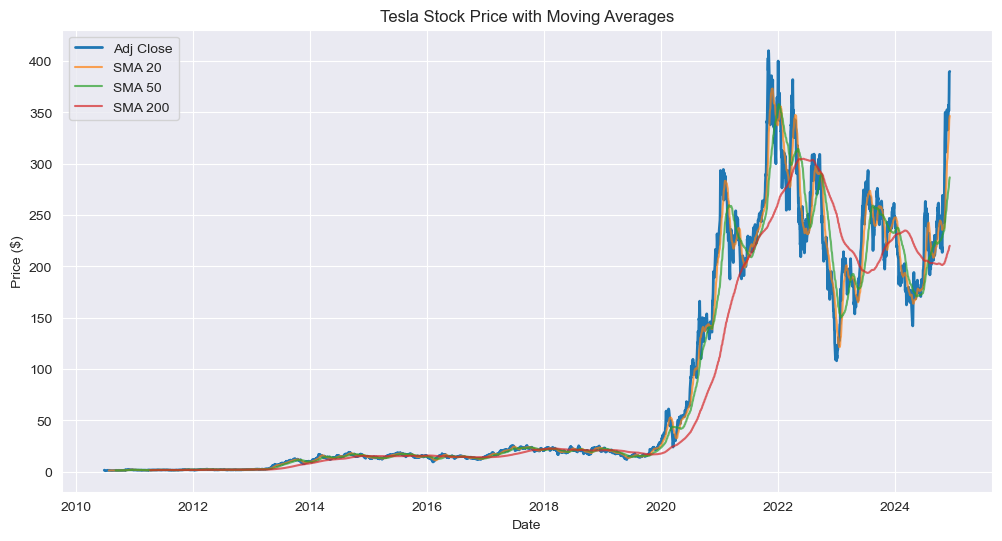

In [17]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Adj Close'], label='Adj Close', linewidth=2)
plt.plot(df['Date'], df['SMA20'], label='SMA 20', alpha=0.7)
plt.plot(df['Date'], df['SMA50'], label='SMA 50', alpha=0.7)
plt.plot(df['Date'], df['SMA200'], label='SMA 200', alpha=0.7)
plt.title('Tesla Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

# **From 2010-2020, Tesla stock price was relatively flat and low, the simple moving averages are tightly packed indicating low volatility**
# **Post 2020 was the breakout period. The price explodes and the simple moving averages spread out drammatically showing momentum**
# **In 2021, the price hits an all time high before a significant drop and subsequent recovery**

# *B. Candlestick Chart (interactive)*

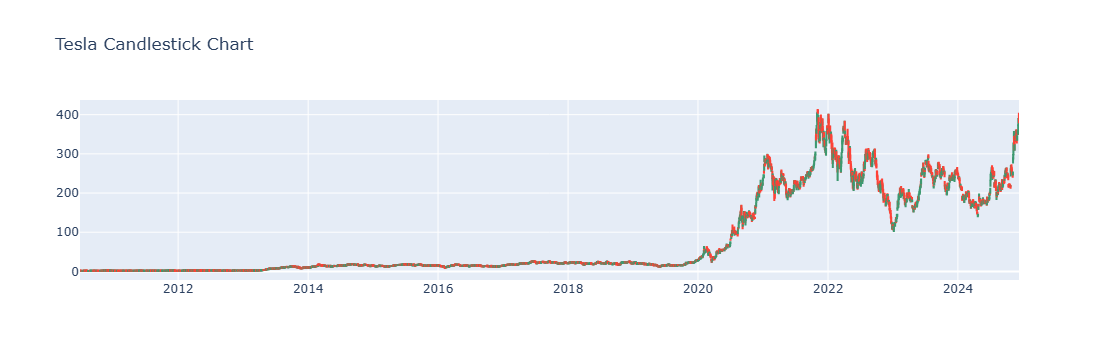

In [19]:
fig = go.Figure(data=[go.Candlestick(
    x=df['Date'],
    open=df['Open'], high=df['High'], low=df['Low'], close=df['Close']
)])
fig.update_layout(title='Tesla Candlestick Chart', xaxis_rangeslider_visible=False)
fig.show()

# *C. Volume over Time*

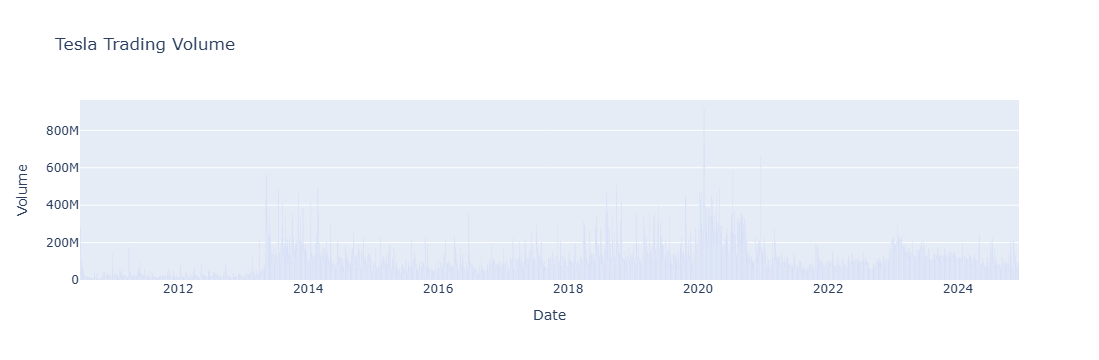

In [20]:
px.bar(df, x='Date', y='Volume', title='Tesla Trading Volume').show()

# **From 2010-2019, the volume bars are generally low and flat, confirming low investor interest and trading activity. In 2020, the bars get much taller, indicating a massive increase in trading volume confirming the strength and conviction of the trend**

# *D. Daily Returns Distribution*

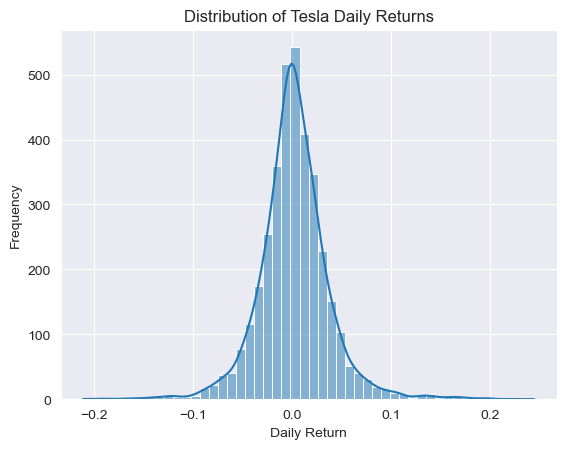

In [21]:
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True)
plt.title('Distribution of Tesla Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

# *E. Rolling Volatility Chart*

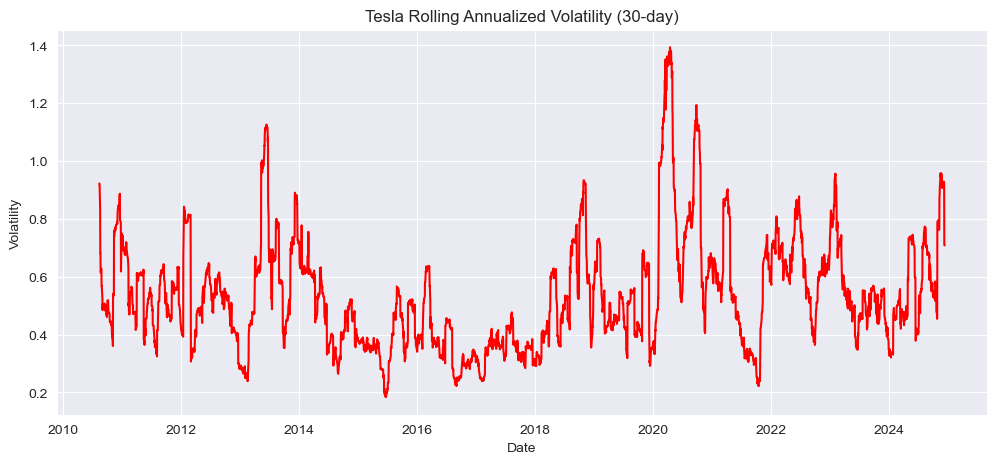

In [22]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Rolling_Volatility'], color='red')
plt.title('Tesla Rolling Annualized Volatility (30-day)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

# **From 2010-2020, volatility was generally low, fluctuating mostly between 0.4 and 0.8. This confirms that the stock was relatively flat and less risky during this period**
# **From 2020-2021 was the hyper growth phase which was highly profitable but also extremely risky as volatility spikes above 1.2**
# **Post 2021, volatility has come down but remains elevated compared to pre-2020 period often spiking between 0.6-0.9**

# *F. Drawdown Chart*

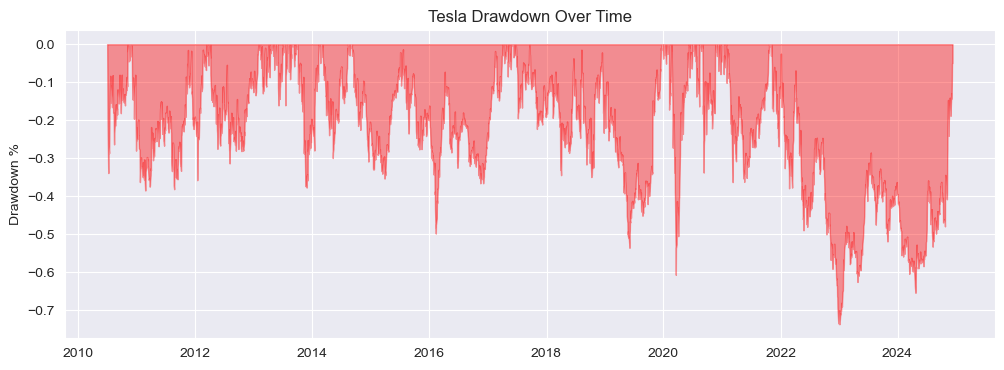

In [23]:
plt.figure(figsize=(12,4))
plt.fill_between(df['Date'], df['Drawdown'], color='red', alpha=0.4)
plt.title('Tesla Drawdown Over Time')
plt.ylabel('Drawdown %')
plt.show()

# **From 2010-2019, drawdowns were relatively small reflecting lower volatility. During this time, the stock was mostly a sleeper. After the massive hike in 2020, the stock price had a monumental fall which reflects high volatility. An investor who bought at the absolute peak in 2020, would suffer a huge loss just to stay invested**

# *G. Cumulative Return Chart*

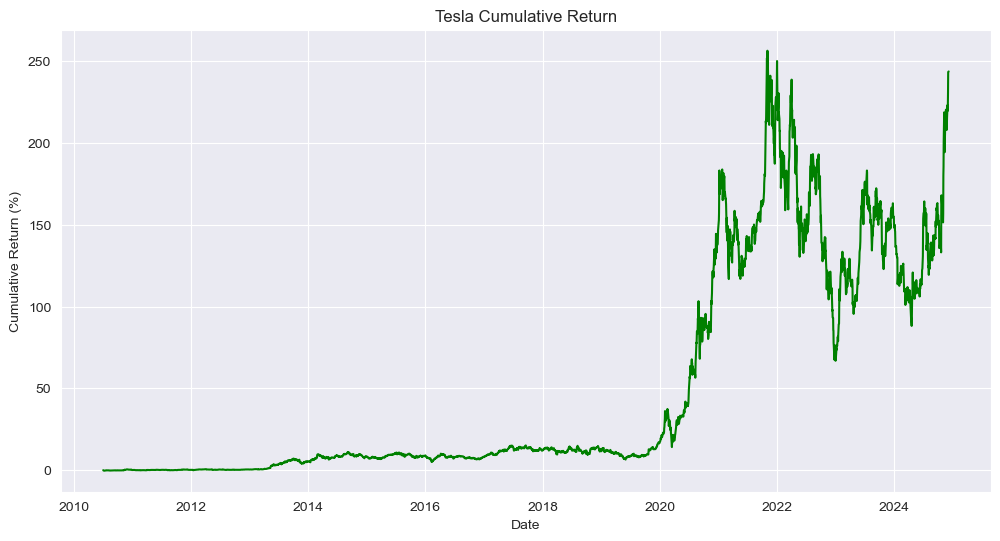

In [24]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Cumulative_Return'], color='green')
plt.title('Tesla Cumulative Return')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.show()

# **Tesla was a low risk stock for a decade. it then transformed into a high volatility, high volume stock in 2020 delivering enormous returns to investors**
# **For 10 years, Tesla was a modest performer and only saw minimal gains**
# **In 2020, the return line shoots peaking well above 250%. This single period delivered the vast majority of the stock's returns**
# **From 2022,the jagged peaks and valley shows drawdowns from the peak followed by recovery**

# **7. Forcasting Future Prices**

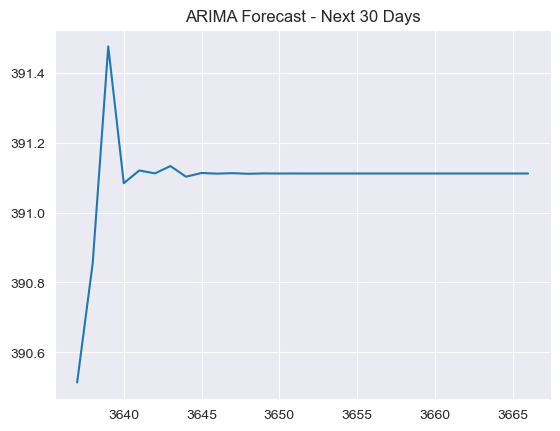

In [26]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model on Adj Close
model = ARIMA(df['Adj Close'], order=(5,1,0))
model_fit = model.fit()

# Forecast next 30 days
forecast = model_fit.forecast(steps=30)
plt.plot(forecast)
plt.title('ARIMA Forecast - Next 30 Days')
plt.show()

# **The forecast starts with a noticeable spike around the x-axis reaching approximately 391.4. This is the first predicted value after the historical data suggesting the model predicts a sharp, immediate jump or a very volatile start. Immediately after the spike, the forecast drops and settles at a flatline. The stabilization line (flat line) showing no further movement for the next month**